## 数据探索

记录针对 `ProcessData/Alpha` 中 ToT/ToA 矩阵的初步探索步骤，为后续深度模型准备输入。

In [1]:
# 基础库导入
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'viridis'

In [2]:
# 数据路径与工具函数
DATA_ROOT = Path('../').resolve()
ALPHA_ROOT = DATA_ROOT / 'Alpha'
ELECTRON_ROOT = DATA_ROOT / 'Electron'

def load_detector_matrix(file_path: Path) -> np.ndarray:
    """Load a single detector text file as a 2D float32 array."""
    matrix = np.loadtxt(file_path, dtype=np.float32)
    if matrix.ndim != 2:
        raise ValueError(f"Unexpected ndim {matrix.ndim} for {file_path}")
    if matrix.shape not in {(100, 100), (256, 256)}:
        raise ValueError(f"Unexpected shape {matrix.shape} for {file_path}")
    return matrix

def matrix_summary(matrix: np.ndarray) -> Dict[str, float]:
    """Compute quick summary metrics for a detector matrix."""
    flat = matrix.ravel()
    nonzero = flat[flat != 0]
    return {
        'min': float(flat.min()),
        'max': float(flat.max()),
        'mean': float(flat.mean()),
        'std': float(flat.std()),
        'nonzero_fraction': float(nonzero.size / flat.size),
        'nonzero_mean': float(nonzero.mean()) if nonzero.size else 0.0,
        'nonzero_std': float(nonzero.std()) if nonzero.size else 0.0,
    }

In [3]:
# 选取一个示例样本 (Alpha, ToT)
def find_first_sample(root: Path, modality: str) -> Path:
    for angle_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        modality_dir = angle_dir / modality
        if not modality_dir.exists():
            continue
        files = sorted(modality_dir.glob('*.txt'))
        if files:
            return files[0]
    raise FileNotFoundError(f'No {modality} files found under {root}')

sample_tot_file = find_first_sample(ALPHA_ROOT, 'ToT')
sample_tot_file

WindowsPath('D:/Project/Timepix/ProcessData/Alpha/15/ToT/1_r0003_track002_ToT.txt')

In [4]:
# 加载示例矩阵并输出统计量
sample_matrix = load_detector_matrix(sample_tot_file)
pd.Series(matrix_summary(sample_matrix))

min                    0.000000
max                 1022.000000
mean                   0.600500
std                   17.866709
nonzero_fraction       0.006200
nonzero_mean          96.854836
nonzero_std          205.339432
dtype: float64

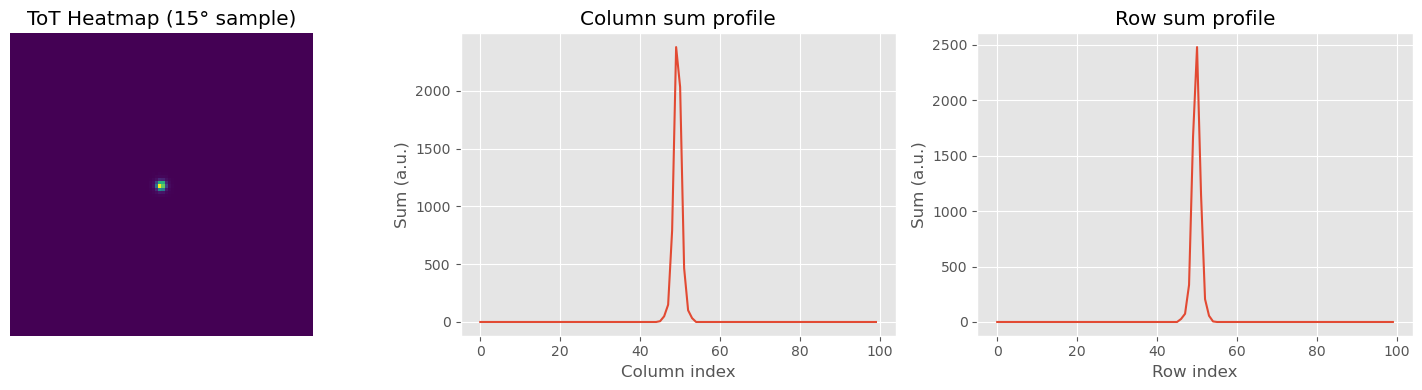

In [5]:
# 可视化矩阵及行列投影
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(sample_matrix)
axes[0].set_title('ToT Heatmap (15° sample)')
axes[0].axis('off')
axes[1].plot(sample_matrix.sum(axis=0))
axes[1].set_title('Column sum profile')
axes[1].set_xlabel('Column index')
axes[1].set_ylabel('Sum (a.u.)')
axes[2].plot(sample_matrix.sum(axis=1))
axes[2].set_title('Row sum profile')
axes[2].set_xlabel('Row index')
axes[2].set_ylabel('Sum (a.u.)')
plt.tight_layout()

In [6]:
# 遍历全部文件收集统计

def collect_particle_stats(root: Path, modalities: tuple[str, ...] = ('ToT', 'ToA')) -> pd.DataFrame:
    records = []
    for angle_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        angle = angle_dir.name
        for modality in modalities:
            modality_dir = angle_dir / modality
            if not modality_dir.exists():
                continue
            for file_path in sorted(modality_dir.glob('*.txt')):
                matrix = load_detector_matrix(file_path)
                flat = matrix.ravel()
                total_sum = float(flat.sum())
                nonzero = flat[flat != 0]
                nz_count = int(nonzero.size)
                if nz_count:
                    nz_sum = float(nonzero.sum())
                    nz_sum_sq = float((nonzero ** 2).sum())
                    nz_mean = float(nonzero.mean())
                    nz_std = float(nonzero.std(ddof=0))
                    nz_min = float(nonzero.min())
                    nz_max = float(nonzero.max())
                else:
                    nz_sum = 0.0
                    nz_sum_sq = 0.0
                    nz_mean = np.nan
                    nz_std = np.nan
                    nz_min = np.nan
                    nz_max = np.nan
                records.append({
                    'particle': root.name,
                    'angle': angle,
                    'modality': modality,
                    'file_name': file_path.name,
                    'file_path': str(file_path),
                    'total_sum': total_sum,
                    'nonzero_count': nz_count,
                    'nonzero_sum': nz_sum,
                    'nonzero_sum_sq': nz_sum_sq,
                    'nonzero_mean': nz_mean,
                    'nonzero_std': nz_std,
                    'nonzero_min': nz_min,
                    'nonzero_max': nz_max,
                })
    return pd.DataFrame.from_records(records)

alpha_stats = collect_particle_stats(ALPHA_ROOT)
electron_stats = collect_particle_stats(ELECTRON_ROOT)
all_stats = pd.concat([alpha_stats, electron_stats], ignore_index=True)
per_file_metrics = all_stats[
    ['particle', 'angle', 'modality', 'file_name', 'total_sum', 'nonzero_count', 'nonzero_mean', 'nonzero_std', 'nonzero_min', 'nonzero_max']
]
per_file_metrics.head()

,particle,angle,modality,file_name,total_sum,nonzero_count,nonzero_mean,nonzero_std,nonzero_min,nonzero_max
0,Alpha,15,ToT,1_r0003_track002_ToT.txt,6005.0,62,96.854836,205.339432,2.0,1022.0
1,Alpha,15,ToT,1_r0004_track001_ToT.txt,5512.0,65,84.800003,177.218536,1.0,764.0
2,Alpha,15,ToT,1_r0006_track001_ToT.txt,4512.0,43,104.930229,201.980820,2.0,871.0
3,Alpha,15,ToT,1_r0007_track001_ToT.txt,5195.0,58,89.568962,183.070175,2.0,804.0
4,Alpha,15,ToT,1_r0008_track001_ToT.txt,5163.0,56,92.196426,185.137939,1.0,740.0


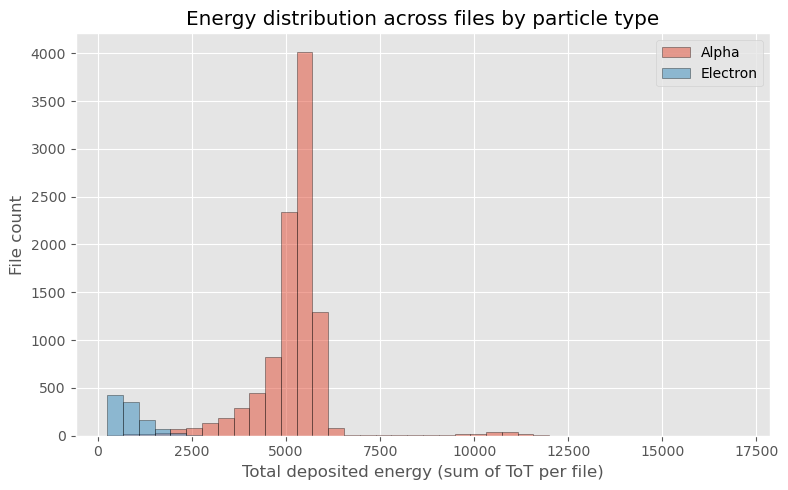

In [7]:
# ToT 沉积能量分布

tot_df = all_stats[all_stats['modality'] == 'ToT'].copy()
if tot_df.empty:
    print('No ToT data found for histogram plotting.')
else:
    energy_bins = np.histogram_bin_edges(tot_df['total_sum'], bins=40)
    fig, ax = plt.subplots(figsize=(8, 5))
    for particle, group in tot_df.groupby('particle'):
        ax.hist(group['total_sum'], bins=energy_bins, alpha=0.5, label=particle, edgecolor='black')
    ax.set_xlabel('Total deposited energy (sum of ToT per file)')
    ax.set_ylabel('File count')
    ax.set_title('Energy distribution across files by particle type')
    ax.legend()
    plt.tight_layout()

In [8]:
# 各角度沉积总量与非零元素统计

group_cols = ['particle', 'angle', 'modality']

# 总沉积量（ToT 代表能量，ToA 代表时间）
total_summary = (
    all_stats
    .groupby(group_cols)
    .agg(
        files=('file_name', 'count'),
        total_sum_sum=('total_sum', 'sum'),
        total_sum_mean=('total_sum', 'mean'),
        total_sum_std=('total_sum', 'std'),
        total_sum_min=('total_sum', 'min'),
        total_sum_max=('total_sum', 'max'),
    )
    .reset_index()
)

total_summary


,particle,angle,modality,files,total_sum_sum,total_sum_mean,total_sum_std,total_sum_min,total_sum_max
0,Alpha,15,ToA,3504,4.022002e+14,1.147832e+11,6.971729e+10,195124992.0,4.103404e+11
1,Alpha,15,ToT,3504,1.926027e+07,5.496652e+03,7.860194e+02,657.0,1.177000e+04
2,Alpha,30,ToA,1441,1.676442e+14,1.163388e+11,7.004159e+10,347734400.0,3.555571e+11
3,Alpha,30,ToT,1441,7.702746e+06,5.345417e+03,1.066203e+03,525.0,1.529600e+04
4,Alpha,45,ToA,3526,3.653069e+14,1.036038e+11,6.414097e+10,-1796875.0,4.477193e+11
5,Alpha,45,ToT,3526,1.874424e+07,5.316008e+03,1.083643e+03,823.0,1.702800e+04
6,Alpha,60,ToA,1552,1.292009e+14,8.324797e+10,5.275228e+10,57046876.0,3.266950e+11
7,Alpha,60,ToT,1552,6.665920e+06,4.295052e+03,1.019234e+03,590.0,1.267300e+04
8,Electron,00,ToA,292,9.713576e+12,3.326567e+10,2.927393e+10,118250000.0,1.867364e+11
9,Electron,00,ToT,292,2.560900e+05,8.770205e+02,4.673227e+02,254.0,3.952000e+03


In [9]:
# 非零元素联合统计

nonzero_summary = (
    all_stats
    .groupby(group_cols)
    .agg(
        files=('file_name', 'count'),
        nonzero_total_count=('nonzero_count', 'sum'),
        nonzero_sum=('nonzero_sum', 'sum'),
        nonzero_sum_sq=('nonzero_sum_sq', 'sum'),
        nonzero_min=('nonzero_min', 'min'),
        nonzero_max=('nonzero_max', 'max'),
    )
    .reset_index()
)

valid_mask = nonzero_summary['nonzero_total_count'] > 0
nonzero_summary['nonzero_mean'] = np.where(
    valid_mask,
    nonzero_summary['nonzero_sum'] / nonzero_summary['nonzero_total_count'],
    np.nan,
)
nonzero_summary['nonzero_var'] = np.where(
    valid_mask,
    nonzero_summary['nonzero_sum_sq'] / nonzero_summary['nonzero_total_count'] - nonzero_summary['nonzero_mean'] ** 2,
    np.nan,
)
nonzero_summary['nonzero_std'] = np.sqrt(np.clip(nonzero_summary['nonzero_var'], a_min=0.0, a_max=None))
nonzero_summary = nonzero_summary.drop(columns=['nonzero_sum', 'nonzero_sum_sq', 'nonzero_var'])
nonzero_summary

,particle,angle,modality,files,nonzero_total_count,nonzero_min,nonzero_max,nonzero_mean,nonzero_std
0,Alpha,15,ToA,3504,200376,2968750.0,4.090938e+09,2.007227e+09,1.183570e+09
1,Alpha,15,ToT,3504,200376,1.0,1.022000e+03,9.612064e+01,1.910791e+02
2,Alpha,30,ToA,1441,81978,1921875.0,4.093266e+09,2.044990e+09,1.181135e+09
3,Alpha,30,ToT,1441,81978,1.0,1.002000e+03,9.396114e+01,1.850277e+02
4,Alpha,45,ToA,3526,179052,-156250.0,4.095016e+09,2.040228e+09,1.181466e+09
5,Alpha,45,ToT,3526,179055,1.0,1.022000e+03,1.046843e+02,2.031677e+02
6,Alpha,60,ToA,1552,63132,1578125.0,4.093344e+09,2.046519e+09,1.165312e+09
7,Alpha,60,ToT,1552,63132,1.0,1.022000e+03,1.055870e+02,1.946617e+02
8,Electron,00,ToA,292,4858,7093750.0,4.076891e+09,1.999501e+09,1.220836e+09
9,Electron,00,ToT,292,4858,1.0,3.430000e+02,5.271511e+01,3.796289e+01


## 后续步骤构想

- 在更多角度采样上扩展统计并对比 Alpha/Electron 分布差异；
- 结合 ToT/ToA 联合特征，准备标准化与数据切分脚本；
- 设计基线分类器验证标签可分性，再迁移到 CNN 结构。